In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# **Upload Raw Dataset**

In [3]:
players_stat = pd.read_csv("/content/Players_round_by_round_stat_raw.csv")

# **Players_stat Overview**

In [4]:
print("Shape:", players_stat.shape)
print("Rows:", players_stat.shape[0])
print("Columns:", players_stat.shape[1])

Shape: (274089, 36)
Rows: 274089
Columns: 36


In [5]:
players_stat.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25


In [6]:
players_stat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274089 entries, 0 to 274088
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         274089 non-null  int64  
 1   team                       274089 non-null  object 
 2   year                       274089 non-null  int64  
 3   career_game_count          274089 non-null  int64  
 4   opponent                   274089 non-null  object 
 5   round                      274089 non-null  object 
 6   result                     274089 non-null  object 
 7   jersey_num                 274089 non-null  int64  
 8   kicks                      272789 non-null  float64
 9   marks                      266038 non-null  float64
 10  handballs                  269656 non-null  float64
 11  disposals                  265636 non-null  float64
 12  goals                      199352 non-null  float64
 13  behinds                    19

**Missing Values and Duplicates**

In [7]:
players_stat.isnull().sum()

,0
id,0
team,0
year,0
career_game_count,0
opponent,0
round,0
result,0
jersey_num,0
kicks,1300
marks,8051


In [8]:
print("Duplicate rows:", players_stat.duplicated().sum())

Duplicate rows: 10


# **Players_stat Cleaning**

In [9]:
# remove duplicate rows
players_stat = players_stat.drop_duplicates()

In [10]:
# Drop column Score
players_stat = players_stat.drop(columns=['score'])

In [11]:
# Fill missing numeric match statistics with 0
stat_columns = [
    'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds',
    'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances',
    'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes',
    'contested_possessions', 'uncontested_possessions', 'contested_marks',
    'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist',
    'percentage_of_game_played'
]
players_stat[stat_columns] = players_stat[stat_columns].fillna(0)

In [12]:
# List of all count columns that should be integers
int_columns = [
    'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds',
    'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances',
    'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes',
    'contested_possessions', 'uncontested_possessions', 'contested_marks',
    'marks_inside_50', 'one_percenters', 'bounces', 'goal_assist'
]
# Convert float values to integers
players_stat[int_columns] = players_stat[int_columns].astype(int)

In [13]:
# Convert match_date column to datetime format
players_stat['match_date'] = pd.to_datetime(players_stat['match_date'])

In [14]:
# Summary Verification
print("Cleaning Complete")
print("New Shape:", players_stat.shape)
print("Remaining Null Values:", players_stat.isnull().sum().sum())
print("Duplicate Rows Remaining:", players_stat.duplicated().sum())

Cleaning Complete
New Shape: (274079, 35)
Remaining Null Values: 0
Duplicate Rows Remaining: 0


# **Convert Cleaned Data to CSV Format**

In [15]:
# Save the cleaned DataFrame to a new CSV file
players_stat.to_csv('Players_round_by_round_stat_cleaned.csv', index=False)
print("Cleaned data successfully saved to CSV!")

Cleaned data successfully saved to CSV!


# **Last Verification**

In [16]:
# Check total number of missing values
total_nulls = players_stat.isnull().sum().sum()
print("Total Missing Values:", total_nulls)

# Check missing values column by column
print("\nMissing Values Per Column:")
print(players_stat.isnull().sum())

# Check total number of duplicate rows
total_duplicates = players_stat.duplicated().sum()
print("\nTotal Duplicate Rows:", total_duplicates)

Total Missing Values: 0

Missing Values Per Column:
id                           0
team                         0
year                         0
career_game_count            0
opponent                     0
round                        0
result                       0
jersey_num                   0
kicks                        0
marks                        0
handballs                    0
disposals                    0
goals                        0
behinds                      0
hit_outs                     0
tackles                      0
rebound_50s                  0
inside_50s                   0
clearances                   0
clangers                     0
free_kicks_for               0
free_kicks_against           0
brownlow_votes               0
contested_possessions        0
uncontested_possessions      0
contested_marks              0
marks_inside_50              0
one_percenters               0
bounces                      0
goal_assist                  0
percentage_of_game

# **Load the Cleaned Datasets to perform the implementation**

In [17]:
# Load datasets
merged_players = pd.read_csv("/content/merged_players.csv")
round_stats = pd.read_csv("/content/Players_round_by_round_stat_cleaned.csv")

In [18]:
# Datasets Shape
print("Merged_Players Shape:", merged_players.shape)
print("Round_Stats Shape:", round_stats.shape)

Merged_Players Shape: (25072, 69)
Round_Stats Shape: (274079, 35)


In [19]:
print("Merged Players Dataset Columns:")
print(merged_players.columns.tolist())

print("\nRound Stats Columns:")
print(round_stats.columns.tolist())

Merged Players Dataset Columns:
['player_id', 'player_name', 'player_full_name', 'first_name', 'last_name', 'born_date', 'debut_date', 'debut_age', 'last_date', 'last_age', 'height', 'weight', 'profile_pic', 'player_link', 'player_common_names', 'player_teams', 'year', 'team', 'is_finals', 'games_played', 'kicks', 'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against', 'brownlow_votes', 'contested_possessions', 'uncontested_possessions', 'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces', 'goal_assists', 'total_score', 'total_fantasy_points', 'total_percentage_played', 'avg_kicks', 'avg_marks', 'avg_handballs', 'avg_disposals', 'avg_goals', 'avg_behinds', 'avg_hit_outs', 'avg_tackles', 'avg_rebound_50s', 'avg_inside_50s', 'avg_clearances', 'avg_clangers', 'avg_free_kicks_for', 'avg_free_kicks_against', 'avg_contested_possessions', 'avg_uncontested_possessi

In [20]:
# Columns in merged players which need to be in integer format
int_columns = ['player_id','year','kicks','marks','handballs','disposals','goals','behinds',
               'hit_outs','tackles','rebound_50s','inside_50s','clearances','clangers','free_kicks_for',
               'free_kicks_against','brownlow_votes','contested_possessions','uncontested_possessions',
               'contested_marks','marks_inside_50','one_percenters','bounces','total_score','total_fantasy_points']
# Convert integer columns
merged_players[int_columns] = (merged_players[int_columns].astype('int64'))

# Date columns
date_columns = ['born_date','debut_date','last_date']
for col in date_columns:
    merged_players[col] = pd.to_datetime(merged_players[col])

In [21]:
print("MERGED PLAYERS INFO")
merged_players.info()

print("\nROUND STATS INFO")
round_stats.info()

MERGED PLAYERS INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25072 entries, 0 to 25071
Data columns (total 69 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   player_id                    25072 non-null  int64         
 1   player_name                  25072 non-null  object        
 2   player_full_name             25072 non-null  object        
 3   first_name                   25072 non-null  object        
 4   last_name                    25072 non-null  object        
 5   born_date                    25072 non-null  datetime64[ns]
 6   debut_date                   25072 non-null  datetime64[ns]
 7   debut_age                    25072 non-null  int64         
 8   last_date                    25072 non-null  datetime64[ns]
 9   last_age                     25072 non-null  int64         
 10  height                       25072 non-null  int64         
 11  weight               

# **From 2020 to 2025 Regular Data**

In [22]:
players = merged_players[(merged_players["year"] >= 2020) &(merged_players["year"] <= 2025)
                                                          &(merged_players["is_finals"] == False)].copy()

round_stats = round_stats[(round_stats["year"] >= 2020) &
                          (round_stats["year"] <= 2025) &
                          (~round_stats["round"].isin(["SF", "QF", "PF", "EF", "GF"]))].copy()

print(players.shape)
print(round_stats.shape)

(3996, 69)
(53944, 35)


In [23]:
players = (players.groupby(["player_id", "player_name"])
    .agg(
        games_played=("games_played", "sum"),
        goals=("goals", "sum"),
        disposals=("disposals", "sum"),
        tackles=("tackles", "sum"),
        clearances=("clearances", "sum"),
        total_fantasy_points=("total_fantasy_points", "sum"),
        contested_possessions=("contested_possessions", "sum"),
    )
    .reset_index()
)

# **Feature Engineering**

In [24]:
# Goals per Game
players['Goals_per_Game'] = (players['goals'] / players['games_played']).fillna(0)

# Disposals per Game
players['Disposals_per_Game'] = (players['disposals'] / players['games_played']).fillna(0)

# Tackles per Game
players['Tackles_per_Game'] = (players['tackles'] / players['games_played']).fillna(0)

# Clearance per Game
players['Clearances_per_Game'] = (players['clearances'] / players['games_played']).fillna(0)

# Fantasy points per Game
players['Fantasy_per_Game'] = (players['total_fantasy_points'] / players['games_played']).fillna(0)

# Contested Possessions per Game
players['Contested_Per_Game'] = (players['contested_possessions'] / players['games_played']).fillna(0)

# Display New Features
players[[
    "player_name",
    "Goals_per_Game",
    "Disposals_per_Game",
    "Tackles_per_Game",
    "Clearances_per_Game",
    "Fantasy_per_Game",
    "Contested_Per_Game"
]].head()

,player_name,Goals_per_Game,Disposals_per_Game,Tackles_per_Game,Clearances_per_Game,Fantasy_per_Game,Contested_Per_Game
0,Jake Aarts,-0.829268,-9.756098,-2.365854,-0.560976,-42.975610,-4.390244
1,Ryan Abbott,1.000000,3.000000,0.000000,0.000000,22.000000,0.000000
2,Gary Ablett,0.875000,16.625000,2.375000,1.375000,61.375000,7.750000
3,Blake Acres,0.301887,20.754717,2.716981,1.707547,80.396226,6.509434
4,Marcus Adams,0.029412,13.411765,1.441176,0.176471,57.529412,5.558824


# **Task 1 : Create Performance Index & Top 10 Most Valueable Players**

In [25]:
players["Performance_Index"] = (
    players["Fantasy_per_Game"].rank(pct=True)
    + players["Disposals_per_Game"].rank(pct=True)
    + players["Goals_per_Game"].rank(pct=True)
    + players["Tackles_per_Game"].rank(pct=True)
    + players["Clearances_per_Game"].rank(pct=True)
    + players["Contested_Per_Game"].rank(pct=True)
) / 6 * 100

In [26]:
# Rank players and select Top 10
top_10_players = players.sort_values("Performance_Index", ascending=False).head(10)

top_10_players[[
    "player_name",
    "games_played",
    "Performance_Index",
    "Fantasy_per_Game",
    "Disposals_per_Game",
    "Goals_per_Game",
    "Tackles_per_Game",
    "Clearances_per_Game"
]].round(2)

,player_name,games_played,Performance_Index,Fantasy_per_Game,Disposals_per_Game,Goals_per_Game,Tackles_per_Game,Clearances_per_Game
69,Marcus Bontempelli,124,97.28,105.48,25.51,1.05,5.64,6.09
650,Christian Petracca,120,94.88,98.73,26.52,0.98,3.60,4.99
180,Patrick Cripps,125,94.40,90.02,25.16,0.61,5.14,6.80
814,Tim Taranto,108,94.00,99.17,25.80,0.58,5.33,4.96
831,Adam Treloar,87,93.41,98.36,28.06,0.63,4.06,4.62
636,Luke Parker,112,93.09,90.38,23.82,0.56,4.67,5.47
199,Nick Daicos,88,92.83,102.03,29.55,0.68,3.34,4.99
611,Lachie Neale,119,92.32,98.99,28.05,0.45,3.84,6.89
357,Isaac Heeney,114,92.32,88.59,19.21,1.58,3.82,3.17
578,Touk Miller,112,92.21,99.88,26.38,0.38,5.47,5.46


# **Visualiztion 1 : Top 10 Players**

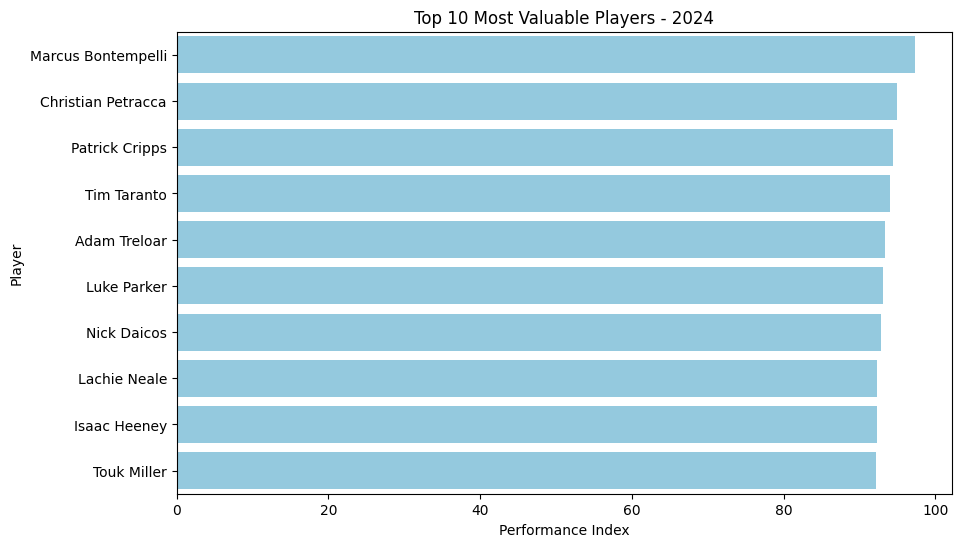

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_10_players,x="Performance_Index",y="player_name", color="skyblue")
plt.title("Top 10 Most Valuable Players - 2024")
plt.xlabel("Performance Index")
plt.ylabel("Player")
plt.show()

# **Task 2 : Finding Most Consistent Players**

In [28]:
# Player-wise Fantasy Point consistency
consistency = round_stats.groupby('player_id').agg(
    Games=('fantasy_points', 'count'),
    Avg_Fantasy=('fantasy_points', 'mean'),
    Fantasy_SD=('fantasy_points', 'std')
).reset_index()

# Coefficient of Variation
consistency['CV'] = (consistency['Fantasy_SD'] / consistency['Avg_Fantasy'])

# Players with at least 30 games
consistency = consistency[consistency['Games'] >= 30]

# Add player names
consistency = consistency.merge(players[['player_id', 'player_name']],on='player_id',how='left')

# Lowest CV = most consistent
consistent_players = consistency.sort_values('CV',ascending=True).head(10)

# Display
consistent_players[['player_name', 'Games', 'Avg_Fantasy', 'Fantasy_SD', 'CV']].round(2)

,player_name,Games,Avg_Fantasy,Fantasy_SD,CV
303,Rory Laird,124,102.90,21.62,0.21
441,Christian Petracca,120,98.73,21.02,0.21
121,Matt Crouch,55,91.49,19.50,0.21
514,Harry Sheezel,67,106.04,23.23,0.22
318,Jake Lloyd,126,88.10,19.71,0.22
519,Jayden Short,114,87.71,19.95,0.23
418,Reilly OBrien,124,89.45,20.42,0.23
438,Scott Pendlebury,114,84.69,19.35,0.23
576,Sam Walsh,107,98.30,22.60,0.23
44,Marcus Bontempelli,124,105.48,24.29,0.23


# **Visualization 2 : Most Consistent Players**

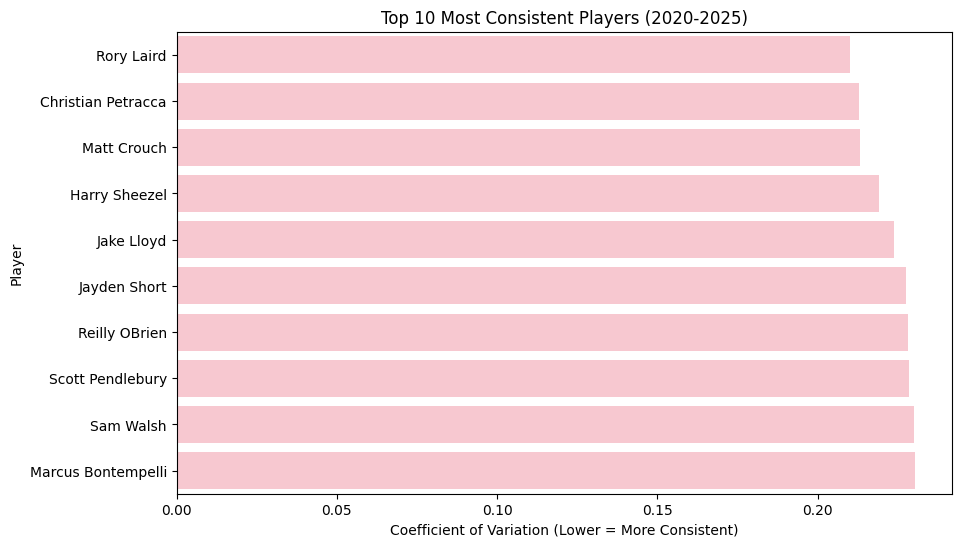

In [29]:
# Top 10 Most Consistent Players

plt.figure(figsize=(10,6))

sns.barplot(data=consistent_players,x='CV',y='player_name', color="pink")

plt.title('Top 10 Most Consistent Players (2020-2025)')
plt.xlabel('Coefficient of Variation (Lower = More Consistent)')
plt.ylabel('Player')
plt.show()

# **Task 3 : Performance Trends**

In [30]:
round_stats['round_num'] = pd.to_numeric(round_stats['round'], errors='coerce')

# First half
first_half = round_stats[round_stats['round_num'] <= 11]
first_half_avg = first_half.groupby('player_id')['fantasy_points'].mean().reset_index()

# Second half
second_half = round_stats[round_stats['round_num'] > 11]
second_half_avg = second_half.groupby('player_id')['fantasy_points'].mean().reset_index()

# Join both results
player_trend = pd.merge(first_half_avg, second_half_avg, on='player_id')
player_trend.columns = ['player_id', 'fantasy_points_H1', 'fantasy_points_H2']

# Performance change
player_trend['Performance_Change'] = player_trend['fantasy_points_H2'] - player_trend['fantasy_points_H1']

# Add player names
player_trend = pd.merge(player_trend, players[['player_id', 'player_name']], on='player_id')

In [31]:
improved_players = player_trend.sort_values('Performance_Change', ascending=False).head(10)
print("TOP 10 MOST IMPROVED PLAYERS")
display(improved_players[['player_name', 'fantasy_points_H1', 'fantasy_points_H2', 'Performance_Change']].round(2))

declined_players = player_trend.sort_values('Performance_Change', ascending=True).head(10)
print("\nTOP 10 MOST DECLINED PLAYERS")
display(declined_players[['player_name', 'fantasy_points_H1', 'fantasy_points_H2', 'Performance_Change']].round(2))

TOP 10 MOST IMPROVED PLAYERS


,player_name,fantasy_points_H1,fantasy_points_H2,Performance_Change
284,Bryce Gibbs,28.00,90.00,62.00
117,Josh Carmichael,8.00,54.00,46.00
953,Will Martyn,13.00,58.00,45.00
121,Ben Cavarra,17.00,55.50,38.50
895,Ashton Moir,5.00,42.80,37.80
54,Jaxon Binns,38.25,75.50,37.25
925,Connor Downie,0.00,36.00,36.00
709,Angus Sheldrick,37.75,73.71,35.96
297,Damon Greaves,27.00,61.14,34.14
389,Josh Jenkins,35.00,69.00,34.00



TOP 10 MOST DECLINED PLAYERS


,player_name,fantasy_points_H1,fantasy_points_H2,Performance_Change
947,Sam Lalor,59.10,4.00,-55.10
312,Cooper Hamilton,51.00,0.00,-51.00
279,Taylor Garner,81.33,37.67,-43.67
670,Ben Ronke,48.67,6.75,-41.92
634,Braydon Preuss,98.67,59.14,-39.52
653,Zach Reid,62.18,23.00,-39.18
917,Angus Clarke,98.00,59.46,-38.54
909,Riley Bice,71.10,32.67,-38.43
153,Charlie Constable,55.25,18.00,-37.25
42,Tom Bellchambers,50.83,15.00,-35.83


# **Visualization 3: Improved Players**

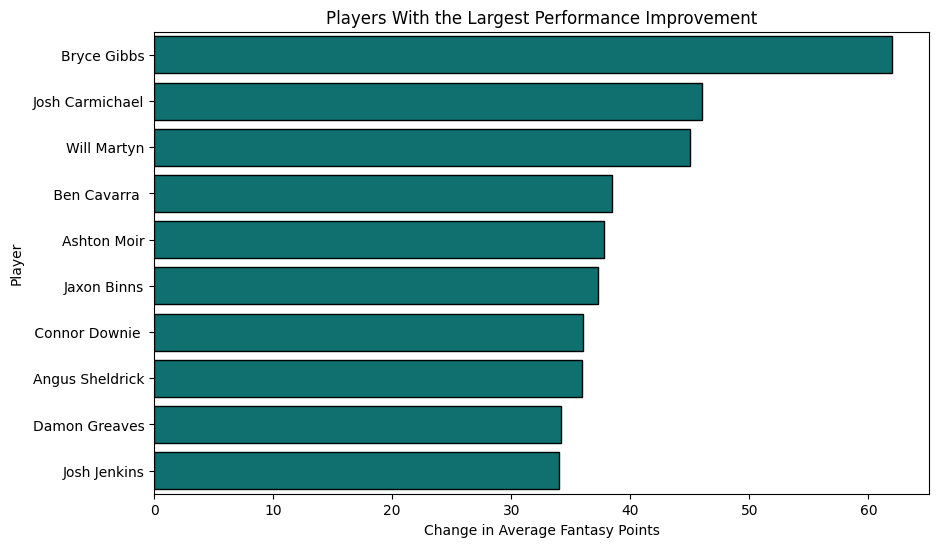

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(data=improved_players,x="Performance_Change",y="player_name",color="teal",edgecolor="black")
plt.title("Players With the Largest Performance Improvement")
plt.xlabel("Change in Average Fantasy Points")
plt.ylabel("Player")

plt.show()

# **Visualization 4: Declined Players**

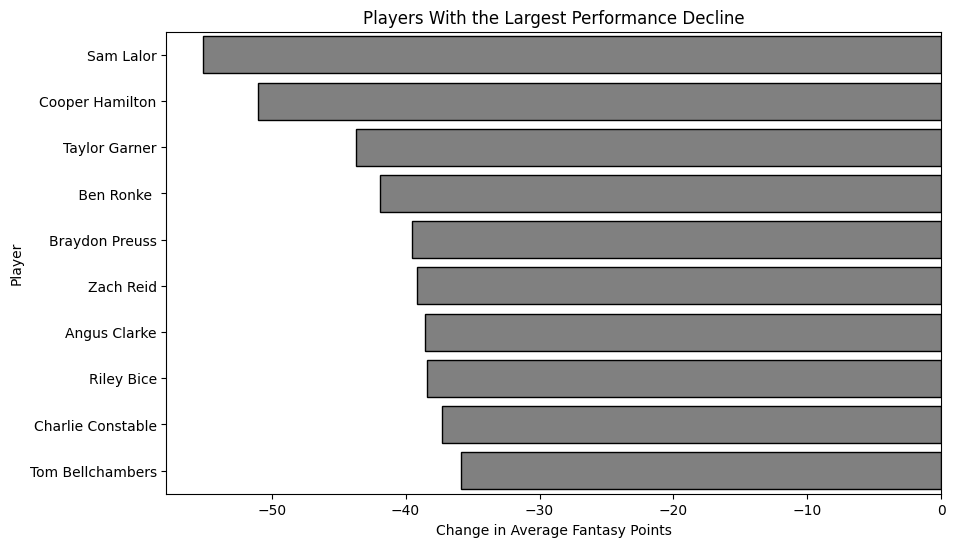

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(data=declined_players,x="Performance_Change",y="player_name",color="grey",edgecolor="black")
plt.title("Players With the Largest Performance Decline")
plt.xlabel("Change in Average Fantasy Points")
plt.ylabel("Player")
plt.show()

# **Task 4: Team Performance Analysis**

In [34]:
# Filter 2020 to 2025 AND Exclude Finals
df_filtered = merged_players[(merged_players["year"] >= 2020)& (merged_players["year"] <= 2025)
                                                             & (merged_players["is_finals"] == False)].copy()

# Clean Team Names
df_filtered["team"] = df_filtered["team"].astype(str).str.strip().str.title()

# Perform Groupby & Ranking
team_performance = (
    df_filtered.groupby("team")
    .agg(
        Player_Games=("player_id", "count"),
        Average_Fantasy=("total_fantasy_points", "mean"),
        Average_Disposals=("disposals", "mean"),
        Average_Clearances=("clearances", "mean"),
        Average_Goals=("goals", "mean"),
        Average_Tackles=("tackles", "mean"),
    )
    .reset_index()
)

In [35]:
# Rank teams by average Fantasy Points
team_performance["Team_Rank"] = (team_performance["Average_Fantasy"].rank(ascending=False, method="min").astype(int))
team_performance = team_performance.sort_values("Team_Rank")

print("Team Performance Ranking, 2020 TO 2025 (EXCLUDING FINALS)")
display(team_performance[[
            "Team_Rank",
            "team",
            "Player_Games",
            "Average_Fantasy",
            "Average_Disposals",
            "Average_Clearances",
            "Average_Goals",
            "Average_Tackles",
        ]].round(2))

Team Performance Ranking, 2020 TO 2025 (EXCLUDING FINALS)


,Team_Rank,team,Player_Games,Average_Fantasy,Average_Disposals,Average_Clearances,Average_Goals,Average_Tackles
6,1,Geelong Cats,208,962.27,222.28,23.35,8.60,37.38
10,2,Melbourne Demons,208,932.85,221.62,22.40,7.62,35.75
1,3,Brisbane Lions,212,932.65,212.35,24.37,8.35,34.17
14,4,St Kilda Saints,217,924.04,216.46,20.75,6.90,35.71
15,5,Sydney Swans,213,918.02,214.46,21.87,7.71,37.31
12,6,Port Adelaide Power,213,916.36,215.60,22.86,7.40,37.15
5,7,Fremantle Dockers,214,897.59,215.36,22.55,6.99,34.32
8,8,Greater Western Sydney Giants,222,886.50,211.20,21.00,7.19,35.23
3,9,Collingwood Magpies,223,869.70,205.09,20.34,6.96,34.99
9,10,Hawthorn Hawks,224,866.29,207.99,19.76,6.90,33.63


# **Visualization 5: Team Ranking**

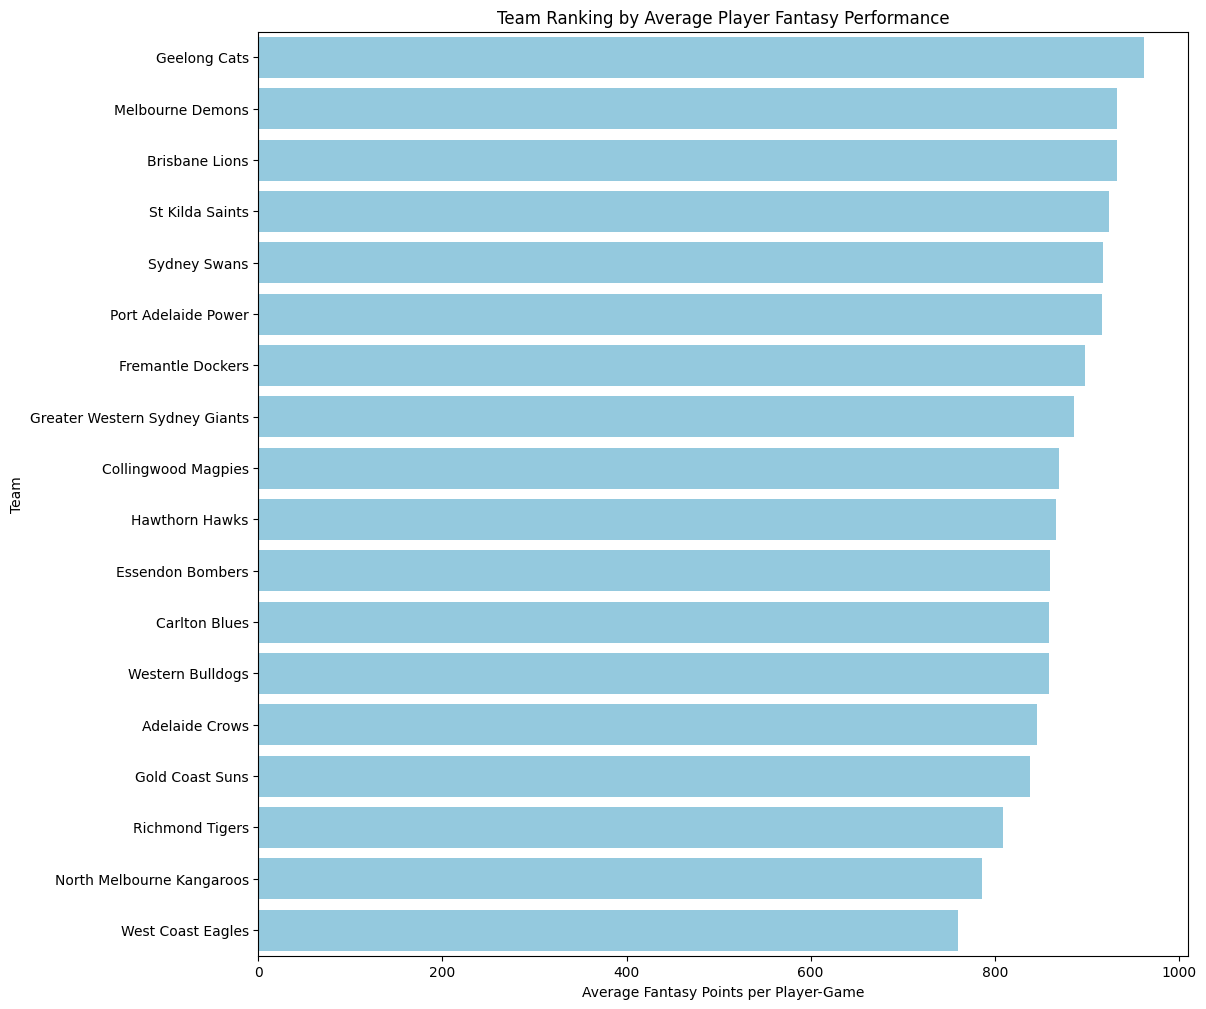

In [36]:
plt.figure(figsize=(12, 12))

sns.barplot(data=team_performance,x="Average_Fantasy",y="team", color= "Skyblue")
plt.title("Team Ranking by Average Player Fantasy Performance")
plt.xlabel("Average Fantasy Points per Player-Game")
plt.ylabel("Team")
plt.show()

# **Task 5: Final Recruitment Recommendations**

In [37]:
# Calculate player stats (games, average, standard deviation)
player_stats = round_stats.groupby('player_id')['fantasy_points'].agg(
    Games='count',
    Avg_Points='mean',
    Std_Dev='std'
).reset_index()

# Calculate consistency (Coefficient of Variation)
player_stats['CV'] = player_stats['Std_Dev'] / player_stats['Avg_Points']

# 3. Merge player trends and names
merged_data = player_stats.merge(player_trend[['player_id', 'Performance_Change']], on='player_id', how='left')
merged_data = merged_data.merge(players[['player_id', 'player_name']], on='player_id', how='left')

# Filter players with at least 30 games
final_players = merged_data[merged_data['Games'] >= 30].copy()

# 5. Calculate final recruitment score
final_players['Recruitment_Score'] = (
    final_players['Avg_Points']
    - (final_players['CV'] * 10)
    + (final_players['Performance_Change'] * 0.5)
)


In [38]:
# Select top 5 players
top_5_players = final_players.sort_values(by='Recruitment_Score', ascending=False).head(5)

# Display results
print("--- TOP 5 RECOMMENDED PLAYERS ---")
display(top_5_players[['player_name', 'Games', 'Avg_Points', 'CV', 'Performance_Change', 'Recruitment_Score']].round(2))

--- TOP 5 RECOMMENDED PLAYERS ---


,player_name,Games,Avg_Points,CV,Performance_Change,Recruitment_Score
73,Marcus Bontempelli,124,105.48,0.23,12.90,109.62
487,Rory Laird,124,102.90,0.21,11.41,106.50
604,Zach Merrett,124,106.39,0.23,4.55,106.36
542,Rowan Marshall,120,101.63,0.29,13.92,105.70
839,Jack Steele,121,104.56,0.23,4.50,104.50


# **Visualization 6 : Top 5 Recruitment Players**


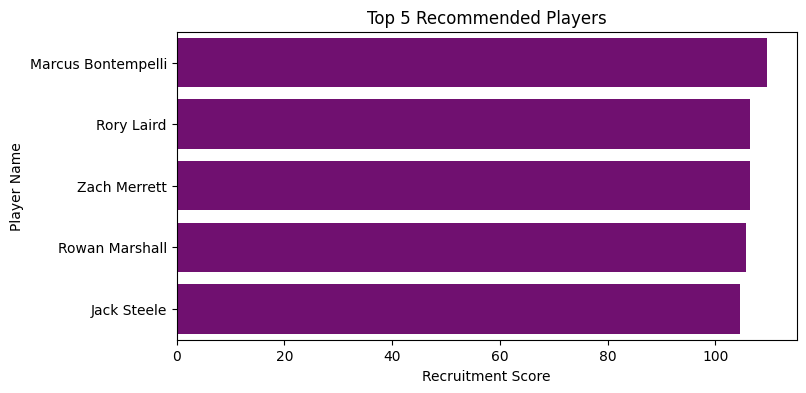

In [39]:
plt.figure(figsize=(8, 4))

sns.barplot(data=top_5_players, x='Recruitment_Score', y='player_name', color='purple')
plt.title('Top 5 Recommended Players')
plt.xlabel('Recruitment Score')
plt.ylabel('Player Name')
plt.show()

# **Visualization 7 : Correlation HeatMap**

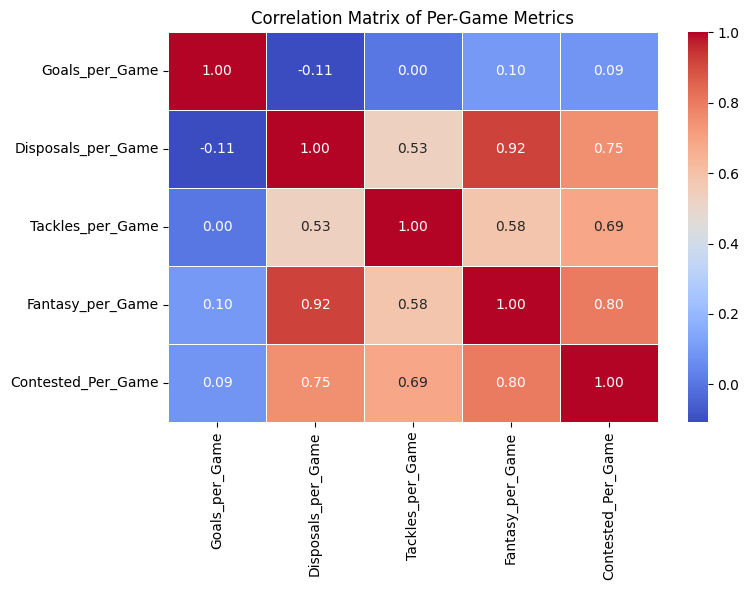

In [40]:
plt.figure(figsize=(8, 6))
cols = [
    'Goals_per_Game',
    'Disposals_per_Game',
    'Tackles_per_Game',
    'Fantasy_per_Game',
    'Contested_Per_Game',
]
corr = players[cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Per-Game Metrics')
plt.tight_layout()
plt.show()

# **Visualization 8 : Histogram with KDE True**

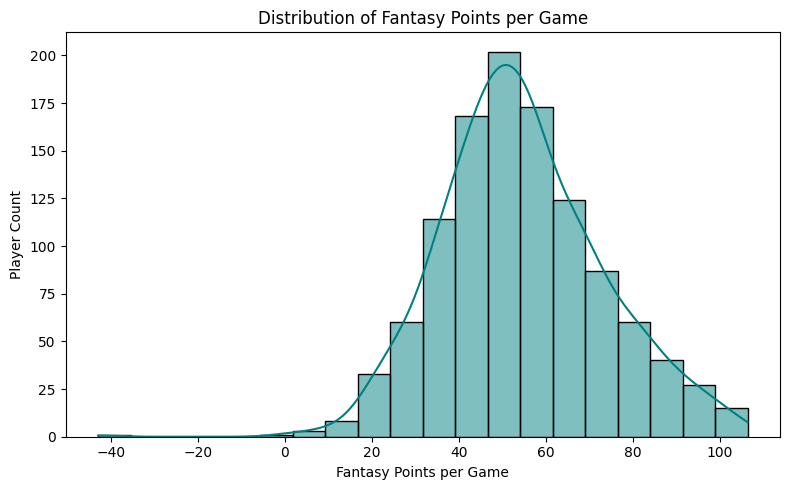

In [41]:
plt.figure(figsize=(8, 5))
sns.histplot(players['Fantasy_per_Game'], kde=True, color='teal', bins=20)

plt.title('Distribution of Fantasy Points per Game')
plt.xlabel('Fantasy Points per Game')
plt.ylabel('Player Count')
plt.tight_layout()
plt.show()

# **Final Recommendation Summary**

In [49]:
# Final Recommendation Summary
final_recommendations = top_5_players.merge(
    players[[
        'player_id',
        'Fantasy_per_Game',
        'Goals_per_Game',
        'Disposals_per_Game',
        'Tackles_per_Game',
        'Clearances_per_Game',
        'Contested_Per_Game'
    ]],on='player_id',how='left')

In [50]:
# Select final columns
final_recommendations = final_recommendations[[
    'player_name',
    'Games',
    'Fantasy_per_Game',
    'Goals_per_Game',
    'Disposals_per_Game',
    'Tackles_per_Game',
    'Clearances_per_Game',
    'Contested_Per_Game',
    'CV',
    'Performance_Change',
    'Recruitment_Score'
]].copy()

# Add ranking
final_recommendations.insert(0, 'Rank', range(1, 6))

# Round values to 2 decimal points
final_recommendations = final_recommendations.round(2)
final_recommendations

,Rank,player_name,Games,Fantasy_per_Game,Goals_per_Game,Disposals_per_Game,Tackles_per_Game,Clearances_per_Game,Contested_Per_Game,CV,Performance_Change,Recruitment_Score
0,1,Marcus Bontempelli,124,105.48,1.05,25.51,5.64,6.09,12.21,0.23,12.90,109.62
1,2,Rory Laird,124,102.90,0.15,28.23,5.95,5.21,11.92,0.21,11.41,106.50
2,3,Zach Merrett,124,106.39,0.35,28.86,4.60,4.14,9.15,0.23,4.55,106.36
3,4,Rowan Marshall,120,101.63,0.52,17.88,3.82,4.05,9.68,0.29,13.92,105.70
4,5,Jack Steele,121,104.56,0.36,24.48,7.51,5.17,11.13,0.23,4.50,104.50


# **Bussiness Insights**

In [51]:
# Business Insights

print("1. Top Player:")
print("The top player showed the strongest overall performance.")

print("\n2. Player Involvement:")
print("Players with more disposals were more involved in the game.")

print("\n3. Scoring:")
print("More goals per game showed better attacking performance.")

print("\n4. Defensive Value:")
print("More tackles showed strong defensive contribution.")

print("\n5. Clearances:")
print("High clearances showed good performance at stoppages.")

print("\n6. Fantasy Points:")
print("Higher fantasy points showed better overall game performance.")

print("\n7. Consistency:")
print("Lower CV means the player performed more consistently.")

print("\n8. Improvement:")
print("A positive performance change means the player improved.")

print("\n9. Decline:")
print("A negative performance change means the player performed worse later.")

print("\n10. Team Performance:")
print("Higher team performance showed stronger overall player output.")

print("\n11. Player Comparison:")
print("Using several stats gives a better player comparison.")

print("\n12. Recruitment:")
print("The best recruits showed strong performance and consistency.")

print("\n13. Experience:")
print("Players with more games provided more reliable performance data.")

print("\n14. Player Value:")
print("Players who perform well in different areas provide more value to a team.")

print("\n15. Final Recommendation:")
print("The recommended players showed good overall performance and future potential.")

1. Top Player:
The top player showed the strongest overall performance.

2. Player Involvement:
Players with more disposals were more involved in the game.

3. Scoring:
More goals per game showed better attacking performance.

4. Defensive Value:
More tackles showed strong defensive contribution.

5. Clearances:
High clearances showed good performance at stoppages.

6. Fantasy Points:
Higher fantasy points showed better overall game performance.

7. Consistency:
Lower CV means the player performed more consistently.

8. Improvement:
A positive performance change means the player improved.

9. Decline:
A negative performance change means the player performed worse later.

10. Team Performance:
Higher team performance showed stronger overall player output.

11. Player Comparison:
Using several stats gives a better player comparison.

12. Recruitment:
The best recruits showed strong performance and consistency.

13. Experience:
Players with more games provided more reliable performance da